<a href="https://colab.research.google.com/github/abyansyah052/NLP-1/blob/main/Week4_Assignment/Tugas_BoW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from timeit import default_timer as timer

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
df = pd.read_csv('/content/Tugas 1A Clean Data.csv')
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Shape: {df.shape}")
df.head()

Shape: (59965, 5)


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,si bagus coba daftar login pdhl isi nik bnr se...,1,0.0,0.0,Negative
1,cepat bantu,5,0.0,0.0,Positive
2,mamtap,5,0.0,0.0,Positive
3,mantap 100 percaya,5,0.0,0.0,Positive
4,bagus bangett,5,0.0,0.0,Positive


In [9]:
corpus = df['content'].dropna().astype(str).tolist()
print(f"Total dokumen: {len(corpus)}")
print("Contoh corpus[0]:", corpus[0])
print("Contoh corpus[1]:", corpus[1])

Total dokumen: 59965
Contoh corpus[0]: si bagus coba daftar login pdhl isi nik bnr sesuai ktp ktp foto dngn tetep login 4x coba
Contoh corpus[1]: cepat bantu


In [10]:
all_words = []
for sentence in corpus:
    for word in sentence.split():
        all_words.append(word)

unique_words = list(set(all_words))
print(f"Total unique words: {len(unique_words)}")
print("Sample:", unique_words[:20])

Total unique words: 5700
Sample: ['ribeud', 'rw', 'system', 'mengatasnamakan', 'mantapz', '2x', 'dann', 'baguss', 'ngarep', 'kmbali', 'massa', 'guaa', 'hbis', 'dowload', 'wak', 'langka', 'reward', 'au', 'tab', 'prioritas']


In [11]:
word_frequencies = Counter(all_words)

sorted_words = sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)

word_to_number = {}
for i, (word, frequency) in enumerate(sorted_words):
    word_to_number[word] = i + 1

print("Top 20 Word Frequencies:")
for word, count in sorted_words[:20]:
    print(f"  {word}: {count}")

print(f"\nTotal vocab size: {len(word_to_number)}")

Top 20 Word Frequencies:
  bagus: 7226
  mantap: 6264
  mudah: 5008
  akun: 4656
  masuk: 4582
  banget: 4231
  bantu: 4185
  login: 4148
  transaksi: 4016
  uang: 3917
  saldo: 3311
  daftar: 3109
  tolong: 3032
  transfer: 2468
  kasih: 2464
  hp: 2427
  ribet: 2302
  pakai: 2285
  salah: 2267
  buka: 2186

Total vocab size: 5700


In [12]:
cv = CountVectorizer(max_features=5000)
bow_matrix = cv.fit_transform(corpus).toarray()

bow_df = pd.DataFrame(bow_matrix, columns=cv.get_feature_names_out())
print(f"BoW Matrix Shape: {bow_df.shape}")
bow_df.head()

BoW Matrix Shape: (59965, 5000)


,00,000,01,02,03,04,05,06,07,08,...,you,your,youtube,yt,yth,yu,yuk,zakat,zaman,zonk
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
def sentiment_label(score):
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

df = df.iloc[:len(corpus)].reset_index(drop=True)
df['sentiment'] = df['score'].apply(sentiment_label)
print(df['sentiment'].value_counts())

x = df['content'].fillna('').astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])
print(f"\nLabel classes: {label_encoder.classes_}")

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Train: {len(xtrain)}, Test: {len(xtest)}")


sentiment
positive    38421
negative    18654
neutral      2890
Name: count, dtype: int64

Label classes: ['negative' 'neutral' 'positive']
Train: 47972, Test: 11993


In [14]:
cv_bow = CountVectorizer(max_features=5000)

start = timer()
xtrain_bow = cv_bow.fit_transform(xtrain).toarray()
print(f"BoW train shape: {xtrain_bow.shape} | time: {timer()-start:.2f}s")

start = timer()
xtest_bow = cv_bow.transform(xtest).toarray()
print(f"BoW test shape : {xtest_bow.shape} | time: {timer()-start:.2f}s")

BoW train shape: (47972, 5000) | time: 1.17s
BoW test shape : (11993, 5000) | time: 0.31s


In [15]:
svm_clf  = LinearSVC()
lr_clf   = LogisticRegression(max_iter=1000)
nb_clf   = MultinomialNB()
xgb_clf  = XGBClassifier(eval_metric='mlogloss', verbosity=0)
rfc_clf  = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt',
                                   min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=42)

def evaluate_model(model, xtest, ytest):
    y_pred     = model.predict(xtest)
    accuracy   = accuracy_score(ytest, y_pred)
    precision  = precision_score(ytest, y_pred, average='weighted', zero_division=0)
    recall     = recall_score(ytest, y_pred, average='weighted', zero_division=0)
    f1         = f1_score(ytest, y_pred, average='weighted', zero_division=0)
    report     = classification_report(ytest, y_pred, zero_division=0)
    cm         = confusion_matrix(ytest, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [16]:
start = timer(); svm_bow  = svm_clf.fit(xtrain_bow, ytrain);  print(f"SVM trained  : {timer()-start:.2f}s")
start = timer(); lr_bow   = lr_clf.fit(xtrain_bow, ytrain);   print(f"LR trained   : {timer()-start:.2f}s")
start = timer(); nb_bow   = nb_clf.fit(xtrain_bow, ytrain);   print(f"NB trained   : {timer()-start:.2f}s")
start = timer(); xgb_bow  = xgb_clf.fit(xtrain_bow, ytrain);  print(f"XGB trained  : {timer()-start:.2f}s")
start = timer(); rfc_bow  = rfc_clf.fit(xtrain_bow, ytrain);  print(f"RFC trained  : {timer()-start:.2f}s")

_, acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm   = evaluate_model(svm_bow,  xtest_bow, ytest)
_, acc_lr,  prec_lr,  rec_lr,  f1_lr,  rep_lr,  cm_lr    = evaluate_model(lr_bow,   xtest_bow, ytest)
_, acc_nb,  prec_nb,  rec_nb,  f1_nb,  rep_nb,  cm_nb    = evaluate_model(nb_bow,   xtest_bow, ytest)
_, acc_xgb, prec_xgb, rec_xgb, f1_xgb, rep_xgb, cm_xgb  = evaluate_model(xgb_bow,  xtest_bow, ytest)
_, acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc   = evaluate_model(rfc_bow,  xtest_bow, ytest)

SVM trained  : 9.65s
LR trained   : 141.58s
NB trained   : 12.51s
XGB trained  : 110.49s
RFC trained  : 10.27s


In [17]:
models = {
    'LinearSVM'         : (acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm),
    'LogisticRegression': (acc_lr,  prec_lr,  rec_lr,  f1_lr,  rep_lr,  cm_lr),
    'NaiveBayes'        : (acc_nb,  prec_nb,  rec_nb,  f1_nb,  rep_nb,  cm_nb),
    'XGBoost'           : (acc_xgb, prec_xgb, rec_xgb, f1_xgb, rep_xgb, cm_xgb),
    'RandomForest'      : (acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc),
}

for name, (acc, prec, rec, f1, rep, cm) in models.items():
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.2f}")
    print(f"  Precision: {prec:.2f}")
    print(f"  Recall   : {rec:.2f}")
    print(f"  F1 Score : {f1:.2f}")
    print("  Classification Report:")
    print(rep)
    print("  Confusion Matrix:")
    print(cm)


  LinearSVM
  Accuracy : 0.84
  Precision: 0.81
  Recall   : 0.84
  F1 Score : 0.82
  Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.77      0.78      3668
           1       0.19      0.04      0.07       579
           2       0.87      0.93      0.90      7746

    accuracy                           0.84     11993
   macro avg       0.62      0.58      0.58     11993
weighted avg       0.81      0.84      0.82     11993

  Confusion Matrix:
[[2839   62  767]
 [ 276   26  277]
 [ 508   48 7190]]

  LogisticRegression
  Accuracy : 0.84
  Precision: 0.82
  Recall   : 0.84
  F1 Score : 0.83
  Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78      3668
           1       0.18      0.04      0.06       579
           2       0.87      0.93      0.90      7746

    accuracy                           0.84     11993
   macro avg       0.62      0.58      0.58

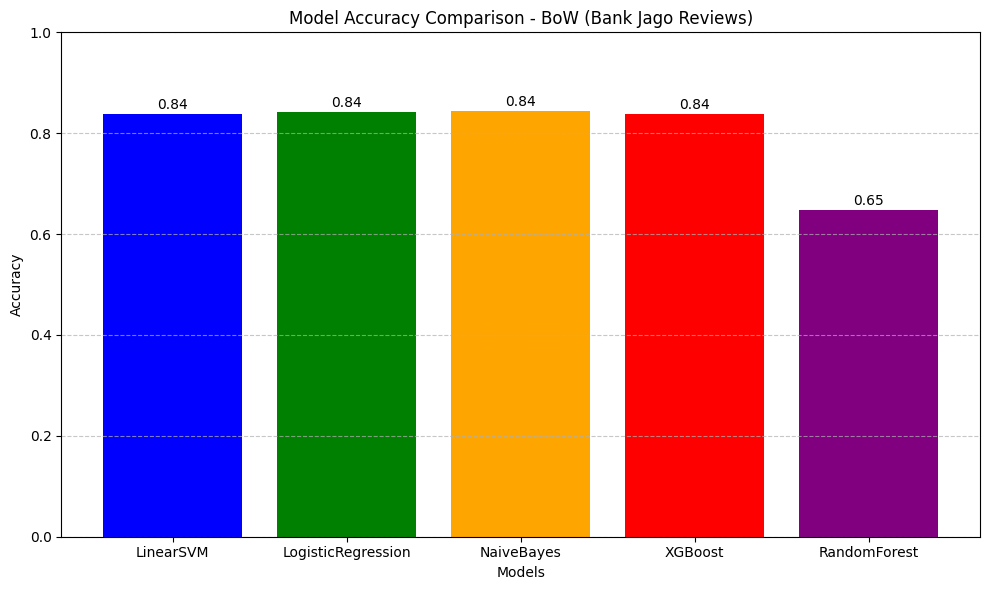

In [18]:
model_names = list(models.keys())
model_accs  = [v[0] for v in models.values()]

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accs, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison - BoW (Bank Jago Reviews)")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(model_accs):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()